# Financial Trading with Python, Second Edition

**Cordell L. Tanny, CFA, FRM, FDP**

**Chapter 16: AI (LLMs) as an Alpha Signal Generator**

Notebook 16.2

Version 2.0 | Last revised: 22 August 2026

**Does the same question get the same answer twice?**

> This notebook is read-only. To run and edit it, select File > Save a copy in Drive.

## 1.0 Introduction

Notebook 16.1 built a corpus of FOMC policy statements. This notebook takes one property of language models and measures it, because it is the property that decides whether anything built on a model can be backtested at all.

The property is repeatability. Every method in this book so far returns the same number every time it runs. A moving average, a z-score, a regression coefficient, a random forest with a fixed seed: run them a thousand times and the thousandth answer matches the first. That is so ordinary it is never stated. A hosted language model comes with no such guarantee, and whether it holds in any particular case is something you measure rather than look up. If scoring the same document twice gives two answers, then an equity curve built on those scores is one draw from a distribution rather than a result, and every validation technique in Chapters 8 through 11 assumes it is looking at a result. How much of that risk is real, and how much of it belongs to the provider you picked, is what Sections 5.0 and 6.0 settle.

This notebook covers:

- Loading the committed corpus and fixing the parameters (Section 2.0)
- What a text score has to specify before it can be traded (Section 3.0)
- Scoring statements with a hosted model, and the prompt design that makes the output usable (Section 4.0)
- Running the same prompt over the same documents ten times (Section 5.0)
- Measuring how far the answers move (Section 6.0)

The chapter text carries the rest: the free baselines this has to beat, what the scores did when turned into positions, the two ways a language model can read the future, and where these tools are worth paying for. This notebook isolates the one finding that has to be watched rather than read about.

You do not need to run Notebook 16.1. The finished corpus ships with the book repository and Section 2.0 loads it directly.

## 2.0 Setup: configuration and loading the corpus

What exactly are we scoring, where does it come from, and what is fixed before we start?

The corpus is a single CSV, `fomc_statements.csv`, holding 232 policy statements. You can supply it in either of two ways and the cell below handles both:

1. Upload it yourself. Open the file browser using the folder icon in the left sidebar of Colab, select the upload icon, and choose `fomc_statements.csv` from the book repository folder. Files uploaded this way live in session storage and are cleared when the runtime disconnects, so expect to upload again after a long break.
2. Do nothing. If the cell finds no uploaded copy, it downloads one from the book repository with `wget`. This needs an internet connection, which Colab has by default.

Either route gives you the same file. Nothing in this notebook fetches from federalreserve.gov, so your results do not depend on the Federal Reserve website being up, on its URL scheme staying the same, or on you having run Notebook 16.1.

Every parameter this notebook uses is set in the cell below, apart from the prompt itself, which belongs to Section 4.0 because it is that section's subject matter rather than a setting.

The load then reports what you actually got rather than only that it worked. Two columns are deliberately sparse and you should expect that: `release_time` is populated on 90 rows, and `tally_for` and `tally_against` on 2, both from a change in statement format in 2026. One column is excluded from scoring by design, since `votes` is a roster of names that changes when the committee rotates rather than when policy changes, so scoring it would measure attendance. `statement` is the scored field throughout.

In [9]:
# ---------------------------------------------------------------------------
# Core imports. The API client is installed in Section 4.0 rather than here,
# so a reader who only wants to see the corpus never installs it.
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# ---------------------------------------------------------------------------
# Corpus location. CORPUS_FILE is the name we look for in the Colab session
# folder first, so an uploaded copy always wins over a download. CORPUS_URL is
# the raw file address in the book repository, used only when no upload exists.
# ---------------------------------------------------------------------------
CORPUS_FILE = "fomc_statements.csv"
CORPUS_URL = (
    "https://raw.githubusercontent.com/PacktPublishing/"
    "Hands-on-Financial-Trading-with-Python-Second-Edition/"
    "main/FINAL/chapter16/fomc_statements.csv"
)

TEXT_COLUMN = "statement"   # the field we score
DATE_COLUMN = "date"        # statement date, not release timestamp

# ---------------------------------------------------------------------------
# Provider presets. Every one of these speaks the OpenAI chat completions
# protocol, so switching between them is two strings rather than a rewrite.
# We use DeepSeek on cost grounds alone and recommend no provider over any
# other. Verify the model name against the provider's current documentation
# before running: these change far more often than books get reprinted.
# ---------------------------------------------------------------------------
PROVIDERS = {
    "deepseek": dict(base_url="https://api.deepseek.com",
                     model="deepseek-chat", secret="DEEPSEEK"),
    "gemini":   dict(base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
                     model="gemini-2.5-flash", secret="GOOGLE_API_KEY"),
    "groq":     dict(base_url="https://api.groq.com/openai/v1",
                     model="llama-3.3-70b-versatile", secret="GROQ_API_KEY"),
}

PROVIDER = "deepseek"

# ---------------------------------------------------------------------------
# Call pacing. Two different delays doing two different jobs: API_CALL_DELAY
# runs after every call to keep us under the rate limit, and API_BASE_DELAY
# backs off after a call has already failed. Prevention and recovery.
# ---------------------------------------------------------------------------
HOSTED_TEMPERATURE = 0.0
API_MAX_RETRIES = 6
API_BASE_DELAY = 2.0        # seconds, doubled on each retry
API_CALL_DELAY = 4.0        # seconds between calls

NOTEBOOK_VERSION = "16.2.0"
RUN_DATE = datetime.now().strftime("%Y-%m-%d")

# ---------------------------------------------------------------------------
# Locate the corpus. An uploaded copy takes priority because a reader who
# rebuilt the corpus in Notebook 16.1 should be working with their own file,
# not silently overwritten by the committed one.
# ---------------------------------------------------------------------------
corpus_path = Path(CORPUS_FILE)

if corpus_path.exists():
    corpus_origin = "uploaded file in the session folder"
else:
    print(f"No local copy of {CORPUS_FILE} found. Downloading from the repository.")
    !wget -q -O {CORPUS_FILE} {CORPUS_URL}
    corpus_origin = "downloaded from the book repository"

# A silent wget failure leaves an empty or missing file, which would surface
# many cells later as an unreadable error. Catch it here instead.
if not corpus_path.exists() or corpus_path.stat().st_size == 0:
    raise FileNotFoundError(
        f"{CORPUS_FILE} is missing or empty. Upload it using the folder icon "
        f"in the left sidebar, or check your internet connection and re-run."
    )

df_fomc = pd.read_csv(corpus_path, parse_dates=[DATE_COLUMN])
df_fomc = df_fomc.sort_values(DATE_COLUMN).reset_index(drop=True)

# Fail loudly if the file is not the one this notebook was written against.
EXPECTED_COLUMNS = [
    "date", "url", "era", "statement", "votes", "tally_for", "tally_against",
    "release_time", "n_words", "is_joint_action", "scraped_at", "script_version",
]
missing_columns = [c for c in EXPECTED_COLUMNS if c not in df_fomc.columns]
assert not missing_columns, f"Corpus is missing expected columns: {missing_columns}"

print(f"Notebook version : {NOTEBOOK_VERSION}")
print(f"Run date         : {RUN_DATE}")
print(f"Provider         : {PROVIDER} | model: {PROVIDERS[PROVIDER]['model']}")

print(f"\nCorpus source : {corpus_origin}")
print(f"Rows, columns : {df_fomc.shape}")
print(f"Date range    : {df_fomc[DATE_COLUMN].min():%Y-%m-%d} to "
      f"{df_fomc[DATE_COLUMN].max():%Y-%m-%d}")
print(f"Built by      : script version {df_fomc['script_version'].unique().tolist()}")

print("\nStatements per era:")
print(df_fomc["era"].value_counts().sort_index().to_string())

print(f"\nColumn completeness (of {len(df_fomc)} rows):")
completeness = pd.DataFrame({
    "populated": df_fomc.notna().sum(),
    "pct": (100 * df_fomc.notna().mean()).round(1),
})
print(completeness.to_string())

# The n_words column in the shipped corpus counts the statement plus the vote
# roster, because it was computed before the two were split apart. We score the
# statement alone, so we derive length from the scored text after reporting the
# file as it ships, and leave n_words in place as provenance only.
df_fomc["words"] = df_fomc[TEXT_COLUMN].str.split().str.len()

print(f"\nJoint actions flagged : {int(df_fomc['is_joint_action'].sum())}")

print(f"Statement word count  : median {df_fomc['words'].median():.0f}, "
      f"min {df_fomc['words'].min()}, max {df_fomc['words'].max()}")
print("  (the n_words column is statement + votes and is not used for analysis)")

Notebook version : 16.2.0
Run date         : 2026-08-22
Provider         : deepseek | model: deepseek-chat

Corpus source : uploaded file in the session folder
Rows, columns : (232, 12)
Date range    : 1997-03-25 to 2026-07-29
Built by      : script version ['16.1.0']

Statements per era:
era
1 legacy     61
2 mid        43
3 modern    128

Column completeness (of 232 rows):
                 populated    pct
date                   232  100.0
url                    232  100.0
era                    232  100.0
statement              232  100.0
votes                  196   84.5
tally_for                2    0.9
tally_against            2    0.9
release_time            90   38.8
n_words                232  100.0
is_joint_action        232  100.0
scraped_at             232  100.0
script_version         232  100.0

Joint actions flagged : 4

Joint actions flagged : 4
Statement word count  : median 297, min 85, max 1394
  (the n_words column is statement + votes and is not used for analysis)


The load reports 232 statements across 12 columns, running from 1997-03-25 to 2026-07-29, built by version 16.1.0 of the corpus script. Over 29 years that averages close to eight statements a year, which is what a calendar of eight scheduled meetings plus occasional unscheduled action produces.

Three things in that output matter later:

- Era split. 61 legacy, 43 mid, and 128 modern. The three groups exist because the Federal Reserve changed its URL scheme twice, but they also track changes in how much the Committee wrote.
- Release time on 38.8 percent of rows. Only 90 statements carry a timestamp, and none of the 61 legacy pages do. Any strategy built on this corpus has to enter on the following day rather than the statement day, because we could time entries precisely for roughly a third of the sample and would be guessing for the rest.
- Statement length. The median is 297 words, the shortest is 85 and the longest is 1,394. A sixteen-fold range means any raw word count measures verbosity rather than content.

What to look for: your row count, date range, and era counts should match the figures above exactly. If they do not, you are working with a different corpus and every number in this notebook will differ.

## 3.0 A signal needs more than sentiment

What turns a score into something you can trade?

Ask a chat model whether a headline is positive and it will tell you. I get sent screenshots of exactly that exchange several times a year, usually with a note asking how to turn it into a strategy. The answer is that you cannot, because positive is not a tradable quantity. It has no direction you can act on, no clock, and no instrument attached to it. Sentiment is a measurement. A signal is a measurement plus five decisions, and the decisions are where the work is.

A tradable text signal needs all five of these specified before you score a single document:

- Document type. Which documents are in scope, and are they comparable to one another? Mixing press releases with earnings calls and news articles gives a score whose meaning changes row by row.
- Release time. When did the information become public, and when could you first act on it? Getting this wrong is the most common way text strategies pick up lookahead bias.
- Holding horizon. How long do you hold after acting? A signal that works at one day and fails at five is a different claim from one that works at both.
- Asset. What do you trade? A score about monetary policy has no obvious mapping to a single stock, but it has a defensible mapping to duration.
- Action. What does a high score mean you do, and what does a low score mean you do? Stated in advance, in the direction economic reasoning supports, not chosen after you see which direction worked.

The design tested in the chapter fixes all five: FOMC statements only, entry at the close of the day after each statement, held one, two, and five days, trading SPY against IEF, with a hawkish reading tilting toward IEF. You may disagree with that mapping, and you are welcome to, but the commitment has to come before the returns are examined.

This notebook stops short of that test and looks instead at whether the score underneath it is stable enough to test at all. If the same document scores differently on Tuesday than it did on Monday, none of the five decisions can be evaluated, because there is no fixed thing to evaluate.

## 4.0 Scoring with a hosted model

What changes when the scorer is a model you rent rather than code you own?

Read this before running anything below:

- **This section costs money.** Scoring is one API call per statement, on an account you have funded. There is no free path through this notebook.
- **The provider here is DeepSeek, chosen on cost grounds alone.** At the time of writing it was the cheapest way to run this particular task, and nothing else recommended it. We are not endorsing it over any alternative. The code speaks the OpenAI chat completions protocol, which most providers expose, so switching means changing a base URL and a model string in the preset in Section 2.0. Check current pricing yourself rather than trusting a number printed in a book.
- **It requires an API key**, stored in Colab Secrets and never typed into a cell. A key pasted into notebook source ends up in your browser history, your Drive, and any copy you share.
- **Provider details go stale.** Free tiers, model names, and rate limits change on a timescale of months, and this book will outlive all of them. If the preset no longer works, that is this section's argument arriving early rather than a mistake in the code.

Three choices in the prompt deserve attention, because prompt design is where most published text-signal research quietly differs:

- **The output is constrained to JSON on a fixed scale.** Asking a model to describe a statement in prose returns something unusable: no two answers are comparable, and parsing them means writing a second classifier to interpret the first. We demand an integer from -5 to +5 and nothing else.
- **The scale is anchored in the prompt.** A model told to rate hawkishness from -5 to +5 with no reference points invents its own, and they drift between calls. Each endpoint and the midpoint are described.
- **The prompt is versioned alongside the model.** Both go into the `model` field, because a score is only reproducible if you know which words produced it.

We score ten statements first rather than the whole corpus. An untested prompt run across 232 documents wastes money and teaches nothing that ten would not have shown.

What to look for: ten integers in range, a rationale short enough to be worth the tokens, and scores that put the 1998, 2008, and 2020 statements below the tightening-cycle ones.

In [4]:
!pip -q install openai

import json, time
from openai import OpenAI
from google.colab import userdata

# ---------------------------------------------------------------------------
# The prompt. Versioned, because a score is only reproducible if you know the
# words that produced it. The scale is anchored at both ends and in the middle
# so the model is not left to invent its own reference points.
# ---------------------------------------------------------------------------
PROMPT_VERSION = "hawkdove-v1"

SYSTEM_PROMPT = (
    "You are a monetary policy analyst. You read FOMC policy statements and "
    "rate the stance of policy they communicate. You answer only with JSON."
)

USER_TEMPLATE = """Rate the monetary policy stance of the FOMC statement below.

Scale:
  -5  strongly dovish: easing, emergency support, or heavy concern about weakness
   0  neutral: policy on hold with balanced risks
  +5  strongly hawkish: tightening, or heavy concern about inflation

Judge only the language of this statement. Do not use anything you know about
what happened afterward.

Return JSON with exactly these keys and nothing else:
  "score": an integer from -5 to 5
  "reason": at most 12 words

STATEMENT:
{statement}"""

# Errors that will never fix themselves on retry. A withdrawn model or a bad
# key fails identically on the sixth attempt as on the first, and on a paid
# account each retry is another charge.
FATAL_ERRORS = ("NotFoundError", "AuthenticationError",
                "PermissionDeniedError", "BadRequestError")


def call_with_retry(client, model, statement):
    """One scored statement, retrying on rate limits and transient failures.

    Providers throttle, and a long run will meet a limit. Without backoff the
    run dies partway through and the money is spent for nothing, which is the
    most common way this kind of experiment is lost.
    """
    for attempt in range(API_MAX_RETRIES):
        try:
            reply = client.chat.completions.create(
                model=model,
                temperature=HOSTED_TEMPERATURE,
                response_format={"type": "json_object"},
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": USER_TEMPLATE.format(statement=statement)},
                ],
            )
            parsed = json.loads(reply.choices[0].message.content)
            return int(parsed["score"]), str(parsed.get("reason", ""))[:80]
        except Exception as exc:
            if type(exc).__name__ in FATAL_ERRORS:
                return np.nan, f"FATAL: {type(exc).__name__}"
            if attempt == API_MAX_RETRIES - 1:
                return np.nan, f"FAILED: {type(exc).__name__}"
            time.sleep(API_BASE_DELAY * (2 ** attempt))


# ---------------------------------------------------------------------------
# Ten statements spanning the range: legacy, crisis, tightening cycle, and the
# 2026 format change. If the prompt cannot separate 2008 from 2005 on ten
# documents, it will not do better on 232.
# ---------------------------------------------------------------------------
probe_dates = ["1997-03-25", "1998-09-29", "2005-12-13", "2008-10-29",
               "2011-08-09", "2015-12-16", "2020-03-23", "2021-12-15",
               "2023-09-20", "2026-07-29"]
probe = df_fomc[df_fomc[DATE_COLUMN].isin(pd.to_datetime(probe_dates))]

settings = PROVIDERS[PROVIDER]
client = OpenAI(api_key=userdata.get(settings["secret"]), base_url=settings["base_url"])
print(f"Provider: {PROVIDER} | model: {settings['model']} | prompt: {PROMPT_VERSION}")
print(f"Scoring {len(probe)} statements...\n")

rows, consecutive_fatal = [], 0
for _, row in probe.iterrows():
    score, reason = call_with_retry(client, settings["model"], row[TEXT_COLUMN])
    rows.append({"date": row[DATE_COLUMN], "llm_score": score, "reason": reason})
    print(f"  {row[DATE_COLUMN]:%Y-%m-%d}  {score:>5}  {reason}")

    consecutive_fatal = consecutive_fatal + 1 if str(reason).startswith("FATAL") else 0
    if consecutive_fatal >= 2:
        print("\nTwo consecutive fatal errors. Stopping rather than working "
              "through the rest with a broken configuration.")
        break
    time.sleep(API_CALL_DELAY)

probe_scores = pd.DataFrame(rows)
print(f"\nFailures: {int(probe_scores['llm_score'].isna().sum())} of {len(probe_scores)}")

Provider: deepseek | model: deepseek-chat | prompt: hawkdove-v1
Scoring 10 statements...

  1997-03-25      4  Tightening policy due to inflation risk, prudent step.
  1998-09-29     -2  Eased slightly due to foreign weakness and financial conditions.
  2005-12-13      4  Rate hike and further firming signal hawkish stance.
  2008-10-29     -5  Emergency 50bp cut, severe slowdown, downside risks, easing bias.
  2011-08-09     -4  Downgraded growth, increased downside risks, extended low rates through mid-2013
  2015-12-16      1  Rate hike but gradual, balanced risks, inflation below target.
  2020-03-23     -5  Emergency support, full range of tools, addressing strains, heavy concern.
  2021-12-15      1  Tapering asset purchases but rates unchanged; slightly hawkish.
  2023-09-20      0  Holds rates, notes solid growth, inflation elevated, but no explicit bias.
  2026-07-29      1  Holds rates, notes solid growth, inflation elevated, but no explicit tightening.

Failures: 0 of 10


The four easing statements come back negative, and 1997 and 2005, the two documents pairing a rate increase with explicit firming language, sit at the top of the scale at 4. The reasons cite specifics from each document rather than restating the prompt, which is the check that matters, since a model pattern-matching on the date would produce something vaguer.

The hawkish end compresses, though, and the reasons show why. The 2015 rate increase scores 1, the 2021 taper acceleration scores 1, and the two statements that hold rates steady score 0 and 1, with the model writing that 2023 holds rates and shows no explicit bias and that 2026 holds rates and shows no explicit tightening. It is scoring the action taken and discounting the guidance attached to it, so the scale is not symmetric and one point of difference at the hawkish end carries less information than one point at the dovish end. Nothing in the prompt asked for that behavior and nothing in the output announces it, so you find it by reading ten reasons.

A second provider widens the gap further. Gemini 2.5 Flash, given the identical prompt over the identical text, scored 1998-09-29 at -4 where DeepSeek scored -2, and 2023-09-20 at 4 where DeepSeek scored 0. Whichever provider you pick becomes part of the definition of the signal, and swapping it later changes the feature rather than refreshing it.

Getting this far took three attempts on an earlier provider, and all three failures are the point rather than incidental trouble.

The model name in the first draft of this notebook returned a 404. It was correct when written and had been withdrawn by the time the cell was run, replaced by a version two releases later. No code was wrong. If the preset no longer resolves when you read this, list the available models and substitute one, and note how little else has to change.

A free tier rate-limited the second attempt, and one statement failed. It happened to be 2020-03-23, among the most dovish documents in the corpus, so the loss would not have been neutral. Retry with backoff recovers from a limit; a fixed delay between calls avoids reaching it. Both are needed, and they are different mechanisms.

The third attempt succeeded, and comparing it against the second turned up something neither was designed to find. Both of those runs used Gemini 2.5 Flash. The same prompt, at temperature zero, on identical text, returned -4 for 2011-08-09 on one run and -5 on the next. One disagreement in nine comparable scores. Temperature zero does not mean deterministic.

Hold on to that. The methods in Chapters 12 through 15 return identical numbers on their thousandth run, and nothing in this book so far has required you to think about it. Section 5.0 turns that single disagreement into a measurement.

## 5.0 Measuring run-to-run variation

If you ask the same model the same question ten times, how many answers do you get?

Section 4.0 answered this by accident, on one statement, comparing two runs. One disagreement is an anecdote. This section runs the same prompt over the same documents ten times and counts.

Two design choices in the sample:

- **Thirty statements at regular intervals**, not the ten hand-picked in Section 4.0. Extreme documents are the easy cases and a model will score them consistently, so measuring only those would understate the disagreement. An even spread across 232 statements covers every era and every chair, and includes the ambiguous documents by construction, which is where a judgment call actually gets made.
- **Ten runs of the same prompt.** Enough passes to see the shape of the spread rather than just its presence. The prompt is unchanged from Section 4.0, because varying it now would mix run-to-run variation with prompt sensitivity, and those are separate questions.

That is 300 calls. Every score is written to disk as it arrives, so a run that dies at call 240 does not cost you the first 239. The cell also pauses after 20 calls so you can check your provider dashboard against your expectations before committing to the rest.

Set `RUN_REPEATS` to `True` to spend the money. Left at `False`, the cell loads the scores committed to the book repository and every later section works without a key.

What to look for: how many of the thirty statements received more than one distinct score across the ten runs.

In [6]:
# ---------------------------------------------------------------------------
# Repeat run configuration. Defaults are set so nothing is spent unless you
# deliberately opt in.
# ---------------------------------------------------------------------------
RUN_REPEATS = False            # True spends money; False loads the committed file
N_REPEAT_DOCS = 30
N_REPEAT_RUNS = 10
REPEAT_FILE = Path("fomc_llm_repeats.csv")
REPEAT_URL = (
    "https://raw.githubusercontent.com/PacktPublishing/"
    "Hands-on-Financial-Trading-with-Python-Second-Edition/"
    "main/FINAL/chapter16/fomc_llm_repeats.csv"
)

# Even spacing across the whole corpus rather than a hand-picked selection.
# linspace with integer rounding gives thirty positions spread from the first
# statement to the last, so every era is represented and the middling
# documents, where the model has an actual judgment to make, are included.
repeat_idx = np.unique(np.linspace(0, len(df_fomc) - 1, N_REPEAT_DOCS).round().astype(int))
repeat_docs = df_fomc.iloc[repeat_idx].reset_index(drop=True)

print(f"Sampled {len(repeat_docs)} statements from "
      f"{repeat_docs[DATE_COLUMN].min():%Y-%m-%d} to "
      f"{repeat_docs[DATE_COLUMN].max():%Y-%m-%d}")
print(repeat_docs["era"].value_counts().sort_index().to_string())
print(f"Calls required if run: {len(repeat_docs) * N_REPEAT_RUNS}")

if RUN_REPEATS:
    print(f"\nProvider: {PROVIDER} | model: {settings['model']} | "
          f"prompt: {PROMPT_VERSION}\n")
    collected, call_no = [], 0
    for run in range(1, N_REPEAT_RUNS + 1):
        for _, row in repeat_docs.iterrows():
            score, _ = call_with_retry(client, settings["model"], row[TEXT_COLUMN])
            collected.append({
                "date": row[DATE_COLUMN],
                "run": run,
                "llm_score": score,
                "model": f"{settings['model']}|{PROMPT_VERSION}",
            })
            call_no += 1

            # Write after every call rather than at the end. On a paid account
            # a crash at call 240 would otherwise throw away real money.
            pd.DataFrame(collected).to_csv(REPEAT_FILE, index=False)

            if call_no == 20:
                print("20 calls done. Check your provider dashboard now and stop "
                      "the cell if the cost is not what you expected.\n")
            time.sleep(API_CALL_DELAY)

        done = pd.DataFrame(collected)
        print(f"  run {run:>2} complete | failures so far: "
              f"{int(done['llm_score'].isna().sum())} of {len(done)}")

    df_repeats = pd.DataFrame(collected)
    print(f"\nWrote {len(df_repeats)} scores to {REPEAT_FILE}")
else:
    if not REPEAT_FILE.exists() or REPEAT_FILE.stat().st_size == 0:
        print("\nDownloading committed repeat scores from the repository.")
        !wget -q -O {REPEAT_FILE} {REPEAT_URL}

    # wget -q writes an empty file on failure rather than nothing at all, so
    # checking existence is not enough. Without this the reader gets an
    # EmptyDataError from pandas, which says nothing about the actual cause.
    if not REPEAT_FILE.exists() or REPEAT_FILE.stat().st_size == 0:
        raise FileNotFoundError(
            f"{REPEAT_FILE} could not be downloaded and is not present locally.\n"
            f"  Either upload it using the folder icon in the left sidebar,\n"
            f"  or set RUN_REPEATS = True to generate it with your own API key.\n"
            f"  Note that generating it makes {len(repeat_docs) * N_REPEAT_RUNS} "
            f"paid API calls."
        )

    df_repeats = pd.read_csv(REPEAT_FILE, parse_dates=["date"])
    print(f"\nLoaded {len(df_repeats)} committed scores "
          f"({df_repeats['run'].nunique()} runs, "
          f"{df_repeats['date'].nunique()} statements)")
    print(f"Model: {df_repeats['model'].unique().tolist()}")

Sampled 30 statements from 1997-03-25 to 2026-07-29
era
1 legacy     8
2 mid        5
3 modern    17
Calls required if run: 300

Provider: deepseek | model: deepseek-chat | prompt: hawkdove-v1

20 calls done. Check your provider dashboard now and stop the cell if the cost is not what you expected.

  run  1 complete | failures so far: 0 of 30
  run  2 complete | failures so far: 0 of 60
  run  3 complete | failures so far: 0 of 90
  run  4 complete | failures so far: 0 of 120
  run  5 complete | failures so far: 0 of 150
  run  6 complete | failures so far: 0 of 180
  run  7 complete | failures so far: 0 of 210
  run  8 complete | failures so far: 0 of 240
  run  9 complete | failures so far: 0 of 270
  run 10 complete | failures so far: 0 of 300

Wrote 300 scores to fomc_llm_repeats.csv


## 6.0 What the repeats show

How far do the answers move, and does it matter?

Three measurements, in increasing order of how much they should worry you:

- **Disagreement rate.** The share of statements that received more than one distinct score across the ten runs. This is the headline number and it answers the question directly.
- **Spread.** For each statement, the distance between its highest and lowest score. A statement scored 3 on nine runs and 4 on one is a different problem from one scored 1 and 5.
- **Modal share.** For each statement, the fraction of runs that agreed with its most common score. This separates an occasional outlier from a genuine coin flip.

The figure plots the spread for every statement in date order, so you can see whether disagreement clusters in a particular era or is spread evenly. Statements from the templated modern era might reasonably be scored more consistently than the terse legacy ones, or the reverse might hold, and the plot is there to answer that rather than to illustrate an answer already given.

What to look for: whether disagreement is rare and small, in which case a single scoring run is a usable approximation, or common and wide, in which case any backtest built on one run is reporting a draw rather than a result.

Usable scores: 300 of 300 (0 failed calls dropped)

Statements scored more than one way : 1 of 30 (3%)
Mean spread across all statements   : 0.03 points
Largest spread on any statement     : 1 points
Mean modal share                    : 0.99
Lowest modal share                  : 0.70

Spread distribution:
        statements
spread            
0               29
1                1

Least stable statements:
      date  distinct  low  high  modal_score  modal_share
2006-06-29         2    3     4            4          0.7
1997-03-25         1    4     4            4          1.0
1999-11-16         1    3     3            3          1.0
2000-11-15         1    2     2            2          1.0
2001-08-21         1   -5    -5           -5          1.0


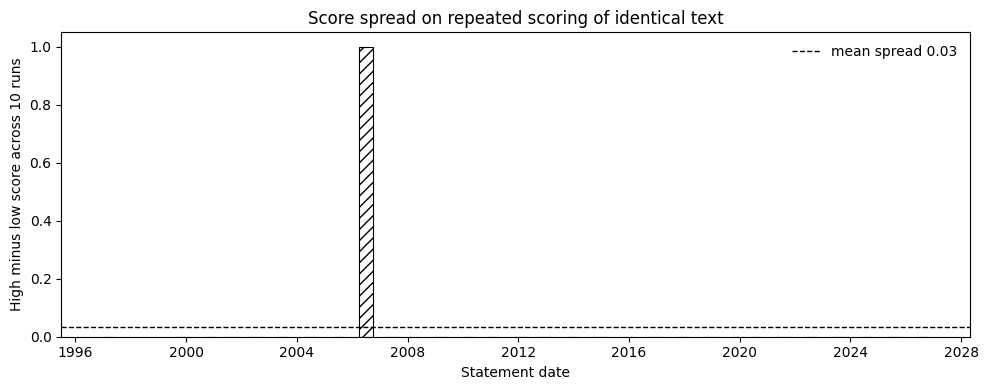

In [7]:
# Drop failed calls before measuring. A failure is a missing observation, not
# a disagreement, and counting it as one would overstate the instability.
scored = df_repeats.dropna(subset=["llm_score"]).copy()
scored["llm_score"] = scored["llm_score"].astype(int)
print(f"Usable scores: {len(scored)} of {len(df_repeats)} "
      f"({int(df_repeats['llm_score'].isna().sum())} failed calls dropped)")

# Per statement: how many distinct answers, how far apart, and how dominant
# the most common answer was.
per_doc = scored.groupby("date")["llm_score"].agg(
    runs="size",
    distinct="nunique",
    low="min",
    high="max",
    modal_score=lambda s: s.mode().iloc[0],
).reset_index()
per_doc["spread"] = per_doc["high"] - per_doc["low"]
per_doc["modal_share"] = [
    (scored.loc[scored["date"] == d, "llm_score"] == m).mean()
    for d, m in zip(per_doc["date"], per_doc["modal_score"])
]

n_docs = len(per_doc)
n_unstable = int((per_doc["distinct"] > 1).sum())

print(f"\nStatements scored more than one way : {n_unstable} of {n_docs} "
      f"({100 * n_unstable / n_docs:.0f}%)")
print(f"Mean spread across all statements   : {per_doc['spread'].mean():.2f} points")
print(f"Largest spread on any statement     : {per_doc['spread'].max()} points")
print(f"Mean modal share                    : {per_doc['modal_share'].mean():.2f}")
print(f"Lowest modal share                  : {per_doc['modal_share'].min():.2f}")

print("\nSpread distribution:")
print(per_doc["spread"].value_counts().sort_index()
      .rename_axis("spread").to_frame("statements").to_string())

print("\nLeast stable statements:")
print(per_doc.nlargest(5, "spread")[
        ["date", "distinct", "low", "high", "modal_score", "modal_share"]]
      .to_string(index=False, formatters={"date": lambda d: d.strftime("%Y-%m-%d")}))

# ---------------------------------------------------------------------------
# Figure. Grayscale-safe: hatched bars and a dashed reference line rather than
# color, since this has to survive being printed in black and white.
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(per_doc["date"], per_doc["spread"], width=180,
       facecolor="white", edgecolor="black", hatch="///", linewidth=0.8)
ax.axhline(per_doc["spread"].mean(), linestyle="--", color="black", linewidth=1,
           label=f"mean spread {per_doc['spread'].mean():.2f}")
ax.set_ylabel("High minus low score across 10 runs")
ax.set_xlabel("Statement date")
ax.set_title("Score spread on repeated scoring of identical text")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

*Figure 16.1: Score spread across ten scoring runs of identical statements.*

Zero calls failed, so all 300 scores are usable and every statement carries a full set of ten runs. Nothing below is distorted by a short sample on one document.

One statement out of thirty, or 3 percent, received more than one distinct score. The 2006-06-29 statement came back as 4 on seven runs and as 3 on the other three, which is the 0.70 modal share in the table and the single bar in the figure. The remaining twenty-nine returned the same number ten times out of ten. Mean spread across the sample is 0.03 points, and the widest spread on any statement is 1.

The figure was drawn to show whether disagreement clusters in a particular era, and it cannot, because one observation does not cluster. The question posed before the run came back unanswered rather than answered, and that is worth stating plainly instead of reading a pattern into a single bar.

The finding is therefore smaller than the anecdote in Section 4.0 suggested, and it points somewhere more useful. Run-to-run variation on this model, at this temperature, with this prompt, is small enough that a single scoring run is a fair approximation of ten. The disagreement that should concern you is the one between providers. The same prompt over the same text put 2023-09-20 four points apart on Gemini and DeepSeek and 1998-09-29 two points apart, against a maximum of one point between ten runs of the same model.

None of this makes a hosted model unusable as a scorer. It makes the configuration part of the signal. The provider, the model string, the prompt text, and the temperature all belong in the definition of the feature and in whatever you commit alongside the backtest, because changing any of them produces a different number rather than a refreshed one. Measuring the variation cost 300 calls and a few cents, which is a cheap price for knowing whether the number in your feature column is a measurement or a draw.

## 7.0 Summary

This notebook took one property of the corpus built in Notebook 16.1 and asked a rented model to turn it into a number. Along the way it produced four results that no amount of prose would have made convincing.

A model string that was correct when written returned a 404 when it ran, a free tier rate-limited a run and dropped one of the most dovish documents in the sample, temperature zero did not produce identical answers, and the scale the model applied was not symmetric around zero. That last one is visible only if you read the reasons rather than the scores, because the model treated the rate decision as the signal and discounted the guidance attached to it.

Section 6.0 put a size on the variation. On this provider, at this temperature, one statement in thirty moved by one point across ten runs, which is small enough to treat a single scoring run as a fair approximation. Given the identical prompt, two providers moved the same statement by four points. The choice of model is a larger decision than the number of times you call it, and both belong in the definition of the feature rather than in the run notes.

That is what separates this method from everything preceding it in the book. A moving average returns the same value on its thousandth run because arithmetic does not have a vendor. A rented model has one, and reproducing your own result a year later depends on pinning what you rented and confirming that the pin still resolves.

Nothing here tested whether the score predicts anything, and that is the chapter's work rather than the notebook's. What the notebook does establish is where the difficulty sits, and there are three places where this would have to improve before it had a chance:

- The prompt. Version hawkdove-v1 asks for an integer and a one-line reason on a fixed scale, and that choice defines the feature. A different prompt produces a different number from the same text, which makes the prompt a parameter like any other. Tuning it until the returns look better is p-hacking conducted in English.
- The data. The corpus took a notebook of its own: three URL schemes, a regular expression pass that recovered 43 statements from the financial crisis years, and a vote roster tangled into the statement text. Whatever the model reads is the product of that work and inherits every decision in it.
- The task. Placing a policy statement on a hawkish to dovish scale has no correct answer to check the model against. Cosine similarity has one, and a model would do that job worse. Here there is nothing to validate a score against except the returns you are trying to predict, which is the least comfortable position in quantitative work.

Set against 232 statements across 29 years, roughly eight a year, the odds of an arrangement this simple producing something tradable were never good. The point of building it was to show you what the attempt involves before you spend a month on your own version.

The chapter text picks up from here, covering the two free baselines a hosted model has to beat before there is any case for paying for it, what happened when these scores became positions and went through the validation process from Chapters 8 through 11, and the work where a model of this kind does pay for itself.

One practical note: RUN_REPEATS ships as False, and Section 6.0 rebuilds the figure and the tables from the 300 scores committed to the book repository beside the corpus, at no cost. If you set it to True to produce your own, set it back afterward so a later run does not spend money you did not intend to spend.